# Factor Analysis with Optimal Number of Factors
## Dog Breed Characteristics Analysis

This notebook performs a comprehensive factor analysis on dog breed traits to identify underlying behavioral and physical dimensions and determine the optimal number of factors.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from kneed import KneeLocator
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Data from CSV File

In [2]:
# Load the dog breeds data
csv_path = './data/demo_data/dogs/breed_traits.csv'
df = pd.read_csv(csv_path)

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head(10))
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (194, 17)

First few rows:
                           Breed  Affectionate With Family  \
0          Retrievers (Labrador)                         5   
1                French Bulldogs                         5   
2           German Shepherd Dogs                         5   
3            Retrievers (Golden)                         5   
4                       Bulldogs                         4   
5                        Poodles                         5   
6                        Beagles                         3   
7                    Rottweilers                         5   
8  Pointers (German Shorthaired)                         5   
9                     Dachshunds                         5   

   Good With Young Children  Good With Other Dogs  Shedding Level  \
0                         5                     5               4   
1                         5                     4               3   
2                         5                     3               4   

## 3. Explore and Prepare Data

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nPercentage of Missing Data:")
print((df.isnull().sum() / len(df) * 100).round(2))

# Separate breed names from numerical features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns for analysis ({len(numeric_cols)}):")
print(numeric_cols)

# Create dataframe with only numeric data
df_numeric = df[numeric_cols].copy()

# Check for any remaining missing values
df_numeric = df_numeric.dropna()
print(f"\nDataset shape after removing NaN: {df_numeric.shape}")

# Store breed names for reference
breed_names = df.loc[df_numeric.index, 'Breed'].values

# Standardize the data (critical for factor analysis)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print(f"\nScaled data shape: {X_scaled.shape}")
print(f"Mean of scaled data: {X_scaled.mean():.6f}")
print(f"Std of scaled data: {X_scaled.std():.6f}")

Missing Values:
Breed                         0
Affectionate With Family      0
Good With Young Children      0
Good With Other Dogs          0
Shedding Level                0
Coat Grooming Frequency       0
Drooling Level                0
Coat Type                     0
Coat Length                   0
Openness To Strangers         0
Playfulness Level             0
Watchdog/Protective Nature    0
Adaptability Level            0
Trainability Level            0
Energy Level                  0
Barking Level                 0
Mental Stimulation Needs      0
dtype: int64

Percentage of Missing Data:
Breed                         0.0
Affectionate With Family      0.0
Good With Young Children      0.0
Good With Other Dogs          0.0
Shedding Level                0.0
Coat Grooming Frequency       0.0
Drooling Level                0.0
Coat Type                     0.0
Coat Length                   0.0
Openness To Strangers         0.0
Playfulness Level             0.0
Watchdog/Protective Natu

## 4. Determine Optimal Number of Factors

### Method 1: Kaiser Criterion (Eigenvalues > 1)
### Method 2: Scree Plot Analysis
### Method 3: Cumulative Variance Explained

In [4]:
# Test different numbers of factors and store variance explained
max_factors = min(len(numeric_cols) - 1, 10)
variance_explained = []
n_factors_range = range(1, max_factors + 1)

for n_factors in n_factors_range:
    fa = FactorAnalysis(n_components=n_factors, random_state=42)
    fa.fit(X_scaled)
    loadings = fa.components_.T
    var_exp = np.sum(loadings**2) / len(numeric_cols)
    variance_explained.append(var_exp)

variance_explained = np.array(variance_explained)
cumulative_variance = np.cumsum(variance_explained)

# Find optimal number of factors using different criteria

# Criterion 1: Kaiser Criterion - compute eigenvalues from correlation matrix
corr_matrix = np.corrcoef(X_scaled.T)
eigenvalues = np.linalg.eigvals(corr_matrix)
eigenvalues_sorted = np.sort(eigenvalues)[::-1]
kaiser_criterion = np.sum(eigenvalues_sorted > 1)

print("="*60)
print("OPTIMAL NUMBER OF FACTORS - ANALYSIS")
print("="*60)
print(f"\n1. KAISER CRITERION (Eigenvalues > 1):")
print(f"   Eigenvalues: {eigenvalues_sorted[:max_factors].round(3)}")
print(f"   → Recommended factors: {kaiser_criterion}")

# Criterion 2: Scree plot elbow method (cumulative variance to 70-80%)
cumvar_70 = np.argmax(cumulative_variance >= 0.70) + 1
cumvar_80 = np.argmax(cumulative_variance >= 0.80) + 1 if np.any(cumulative_variance >= 0.80) else max_factors

print(f"\n2. CUMULATIVE VARIANCE EXPLAINED:")
for i, (n, cum_var) in enumerate(zip(n_factors_range, cumulative_variance)):
    print(f"   {n} factors: {cum_var*100:.1f}%")
print(f"   → Factors for 70% variance: {cumvar_70}")
print(f"   → Factors for 80% variance: {cumvar_80}")

# Criterion 3: Scree plot - look for elbow
print(f"\n3. INDIVIDUAL VARIANCE EXPLAINED PER FACTOR:")
for i, var in enumerate(variance_explained, 1):
    print(f"   Factor {i}: {var*100:.1f}%")

# Recommendation
print("\n" + "="*60)
optimal_factors = kaiser_criterion
if kaiser_criterion < 2:
    optimal_factors = cumvar_70
    print(f"RECOMMENDATION: Using 70% cumulative variance ({cumvar_70} factors)")
else:
    print(f"RECOMMENDATION: Using Kaiser Criterion ({kaiser_criterion} factors)")
print("="*60)

OPTIMAL NUMBER OF FACTORS - ANALYSIS

1. KAISER CRITERION (Eigenvalues > 1):
   Eigenvalues: [3.512 1.689 1.513 1.419 0.94  0.898 0.721 0.63  0.606 0.55 ]
   → Recommended factors: 4

2. CUMULATIVE VARIANCE EXPLAINED:
   1 factors: 20.4%
   2 factors: 49.0%
   3 factors: 85.9%
   4 factors: 129.3%
   5 factors: 176.9%
   6 factors: 226.8%
   7 factors: 279.8%
   8 factors: 334.4%
   9 factors: 390.2%
   10 factors: 446.8%
   → Factors for 70% variance: 3
   → Factors for 80% variance: 3

3. INDIVIDUAL VARIANCE EXPLAINED PER FACTOR:
   Factor 1: 20.4%
   Factor 2: 28.6%
   Factor 3: 36.9%
   Factor 4: 43.4%
   Factor 5: 47.6%
   Factor 6: 49.9%
   Factor 7: 53.0%
   Factor 8: 54.6%
   Factor 9: 55.8%
   Factor 10: 56.7%

RECOMMENDATION: Using Kaiser Criterion (4 factors)


## 5. Perform Factor Analysis with Optimal Number of Factors

In [5]:
# Perform Factor Analysis with the optimal number of factors
fa_model = FactorAnalysis(n_components=optimal_factors, random_state=42, max_iter=1000)
factor_scores = fa_model.fit_transform(X_scaled)

# Store results
loadings = fa_model.components_.T
factor_loadings_df = pd.DataFrame(
    loadings,
    index=numeric_cols,
    columns=[f'Factor {i+1}' for i in range(optimal_factors)]
)

# Create scores dataframe
factor_scores_df = pd.DataFrame(
    factor_scores,
    columns=[f'Factor {i+1}' for i in range(optimal_factors)],
    index=df_numeric.index
)

# Add breed names back
factor_scores_df['Breed'] = breed_names

print(f"✓ Factor Analysis completed with {optimal_factors} factors")
print(f"\nFactor Loadings Matrix ({len(numeric_cols)} variables × {optimal_factors} factors):")
print(factor_loadings_df.round(3))

✓ Factor Analysis completed with 4 factors

Factor Loadings Matrix (14 variables × 4 factors):
                            Factor 1  Factor 2  Factor 3  Factor 4
Affectionate With Family      -0.518     0.415     0.107     0.147
Good With Young Children      -0.440     0.318    -0.213    -0.108
Good With Other Dogs          -0.297     0.173    -0.481    -0.421
Shedding Level                -0.195     0.051     0.161    -0.302
Coat Grooming Frequency        0.030     0.160    -0.097     0.266
Drooling Level                 0.056     0.476     0.523    -0.394
Openness To Strangers         -0.490     0.291    -0.218     0.051
Playfulness Level             -0.740     0.039    -0.113     0.173
Watchdog/Protective Nature     0.081     0.041     0.554     0.367
Adaptability Level            -0.595     0.436    -0.078     0.198
Trainability Level            -0.527     0.096     0.188     0.004
Energy Level                  -0.652    -0.507     0.091    -0.189
Barking Level                 -0.2

## 6. Assign Meaningful Names to Factors

In [6]:
# Function to generate meaningful, DISTINCT factor names based on loadings for dog breeds
def assign_factor_names_dogs(loadings_df):
    """
    Analyze factor loadings and assign UNIQUE semantic names based on top contributing variables.
    Specialized for dog breed characteristics - ensures each factor gets a distinct name.
    """
    factor_names = {}
    factor_interpretations = {}
    assigned_themes = set()  # Track themes already used
    
    for factor_col in loadings_df.columns:
        loadings = loadings_df[factor_col]
        
        # Get top 5 positive and negative loading variables for better analysis
        top_positive = loadings.nlargest(5)
        top_negative = loadings.nsmallest(5)
        
        # Extract variable names and clean them
        top_var_names = [var.replace(' Level', '').replace(' With', '').replace(' Nature', '').lower() 
                        for var in top_positive.index]
        bottom_var_names = [var.replace(' Level', '').replace(' With', '').replace(' Nature', '').lower() 
                           for var in top_negative.index]
        
        # Analyze dominant characteristics in top variables
        all_top_names = ' '.join(top_var_names)
        
        # Build a characteristic score for this factor
        characteristic_scores = {
            'family': sum(1 for word in top_var_names if 'family' in word or 'affectionate' in word or 'children' in word),
            'social': sum(1 for word in top_var_names if 'stranger' in word or 'good with' in word or 'playfulness' in word),
            'protection': sum(1 for word in top_var_names if 'watchdog' in word or 'protective' in word or 'barking' in word),
            'activity': sum(1 for word in top_var_names if 'energy' in word or 'trainability' in word or 'stimulation' in word),
            'maintenance': sum(1 for word in top_var_names if 'shedding' in word or 'coat' in word or 'grooming' in word or 'drooling' in word),
            'adaptability': sum(1 for word in top_var_names if 'adaptability' in word or 'flexible' in word)
        }
        
        # Find dominant characteristic(s) and assign name accordingly
        dominant = max(characteristic_scores, key=characteristic_scores.get)
        dominant_score = characteristic_scores[dominant]
        
        # Create unique names based on dominant characteristic AND the actual top variables
        if dominant == 'family' and dominant_score > 0:
            # Check if it's specifically about family affection vs. children compatibility
            if 'affectionate with family' in ' '.join(top_positive.index):
                name = "Family Affection & Bonding Capacity"
            elif 'good with young children' in ' '.join(top_positive.index):
                name = "Child-Friendly & Gentle Temperament"
            else:
                name = "Social Family Orientation"
                
        elif dominant == 'social' and dominant_score > 0:
            # Social factors but distinguish from family
            if 'playfulness' in all_top_names:
                name = "Playfulness & Openness to Strangers"
            else:
                name = "Social Compatibility & Sociability"
                
        elif dominant == 'protection' and dominant_score > 0:
            # Protective instincts
            name = "Guard Dog Instincts & Vigilance"
            
        elif dominant == 'activity' and dominant_score > 0:
            # Activity and intelligence
            if 'stimulation' in all_top_names:
                name = "High Energy & Mental Challenge Needs"
            elif 'trainability' in all_top_names:
                name = "Trainability & Cognitive Ability"
            else:
                name = "Energy Level & Engagement Drive"
                
        elif dominant == 'maintenance' and dominant_score > 0:
            # Grooming and shedding characteristics
            if 'drooling' in all_top_names:
                name = "Grooming Demands & Coat Care"
            elif 'shedding' in all_top_names:
                name = "Shedding & Coat Maintenance"
            else:
                name = "Physical Grooming Requirements"
                
        elif dominant == 'adaptability' and dominant_score > 0:
            name = "Environmental Adaptability"
            
        else:
            # Fallback: create unique name from top 2 variables
            var1 = top_var_names[0].title()
            var2 = top_var_names[1].title() if len(top_var_names) > 1 else ""
            if var2:
                name = f"{var1} & {var2}"
            else:
                name = f"{var1} Dominance"
        
        # Ensure uniqueness - if name is already used, add distinction
        counter = 1
        original_name = name
        while name in assigned_themes:
            # Add a distinguishing suffix based on the top variable
            suffix = f"({top_var_names[counter % len(top_var_names)].title()})"
            name = f"{original_name} {suffix}"
            counter += 1
        
        assigned_themes.add(name)
        
        factor_interpretations[factor_col] = {
            'name': name,
            'top_variables': list(top_positive.index),
            'top_loadings': top_positive.values,
            'bottom_variables': list(top_negative.index),
            'bottom_loadings': top_negative.values,
            'characteristic': dominant
        }
    
    return factor_interpretations

# Assign names to factors
factor_interp = assign_factor_names_dogs(factor_loadings_df)

print("\n" + "="*70)
print("FACTOR NAMES AND INTERPRETATIONS - DOG BREEDS")
print("="*70)

factor_name_mapping = {}
for factor_col, details in factor_interp.items():
    factor_num = factor_col.split()[-1]
    factor_name_mapping[factor_col] = details['name']
    
    print(f"\nFactor {factor_num}: {details['name'].upper()}")
    print(f"Dominant Dimension: {details['characteristic'].upper()}")
    print("-" * 70)
    print("\nTop Contributing Variables (Positive Loadings):")
    for var, loading in zip(details['top_variables'], details['top_loadings']):
        print(f"  + {var:45s} {loading:7.3f}")
    
    print("\nBottom Contributing Variables (Negative Loadings):")
    for var, loading in zip(details['bottom_variables'], details['bottom_loadings']):
        print(f"  - {var:45s} {loading:7.3f}")

print("\n" + "="*70)

# Create a summary table
summary_df = pd.DataFrame([
    {
        'Factor': col,
        'Name': factor_name_mapping[col],
        'Dimension': factor_interp[col]['characteristic'].upper(),
        'Variance Explained': f"{variance_explained[i]*100:.1f}%",
        'Cumulative': f"{cumulative_variance[i]*100:.1f}%"
    }
    for i, col in enumerate(factor_loadings_df.columns)
])

print("\nFACTOR SUMMARY TABLE:")
print(summary_df.to_string(index=False))
print("\n" + "="*70)


FACTOR NAMES AND INTERPRETATIONS - DOG BREEDS

Factor 1: GROOMING DEMANDS & COAT CARE
Dominant Dimension: MAINTENANCE
----------------------------------------------------------------------

Top Contributing Variables (Positive Loadings):
  + Watchdog/Protective Nature                      0.081
  + Drooling Level                                  0.056
  + Coat Grooming Frequency                         0.030
  + Shedding Level                                 -0.195
  + Barking Level                                  -0.266

Bottom Contributing Variables (Negative Loadings):
  - Playfulness Level                              -0.740
  - Mental Stimulation Needs                       -0.657
  - Energy Level                                   -0.652
  - Adaptability Level                             -0.595
  - Trainability Level                             -0.527

Factor 2: SOCIAL FAMILY ORIENTATION
Dominant Dimension: FAMILY
-----------------------------------------------------------------

## 7. Interpret Factor Loadings

In [7]:
# Analyze and interpret factor loadings
print("\nFACTOR INTERPRETATION - DETAILED VIEW")
print("="*60)

for factor_idx in range(optimal_factors):
    factor_name = f'Factor {factor_idx + 1}'
    factor_semantic_name = factor_name_mapping.get(factor_name, "")
    loadings_col = factor_loadings_df[factor_name].abs()
    top_features = loadings_col.nlargest(5)
    
    print(f"\n{factor_name}: {factor_semantic_name}")
    print("-" * 60)
    for var, loading in top_features.items():
        actual_loading = factor_loadings_df.loc[var, factor_name]
        direction = "+" if actual_loading > 0 else "-"
        print(f"  {direction} {var:42s} {actual_loading:7.3f}")

# Summary statistics on factor scores
print("\n\nFACTOR SCORES SUMMARY")
print("="*60)
for col in factor_scores_df.columns:
    if col != 'Breed':
        factor_semantic_name = factor_name_mapping.get(col, "")
        print(f"\n{col}: {factor_semantic_name}")
        print(f"  Mean: {factor_scores_df[col].mean():7.3f}")
        print(f"  Std:  {factor_scores_df[col].std():7.3f}")
        print(f"  Min:  {factor_scores_df[col].min():7.3f}")
        print(f"  Max:  {factor_scores_df[col].max():7.3f}")


FACTOR INTERPRETATION - DETAILED VIEW

Factor 1: Grooming Demands & Coat Care
------------------------------------------------------------
  - Playfulness Level                           -0.740
  - Mental Stimulation Needs                    -0.657
  - Energy Level                                -0.652
  - Adaptability Level                          -0.595
  - Trainability Level                          -0.527

Factor 2: Social Family Orientation
------------------------------------------------------------
  - Energy Level                                -0.507
  + Drooling Level                               0.476
  + Adaptability Level                           0.436
  + Affectionate With Family                     0.415
  + Good With Young Children                     0.318

Factor 3: High Energy & Mental Challenge Needs
------------------------------------------------------------
  + Watchdog/Protective Nature                   0.554
  + Drooling Level                              

## 8. Visualize Results

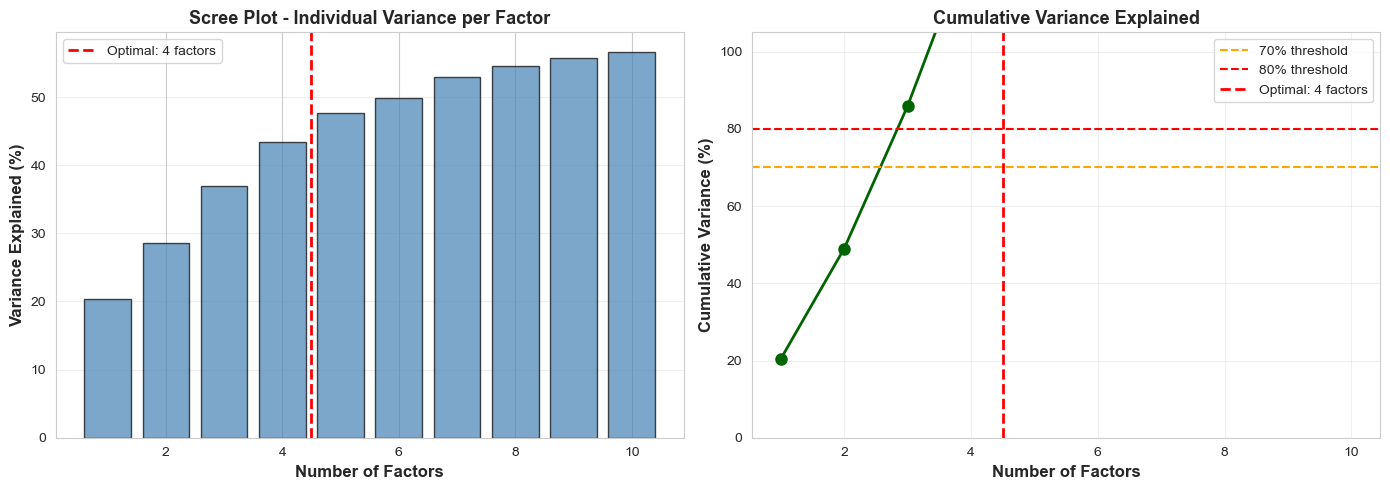

✓ Scree plot saved


In [8]:
### 8.1 Scree Plot - Variance Explained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance explained
axes[0].bar(range(1, len(variance_explained) + 1), variance_explained * 100, 
            alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(x=optimal_factors + 0.5, color='red', linestyle='--', 
                linewidth=2, label=f'Optimal: {optimal_factors} factors')
axes[0].set_xlabel('Number of Factors', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Scree Plot - Individual Variance per Factor', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# Cumulative variance explained
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, 
            marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[1].axhline(y=70, color='orange', linestyle='--', linewidth=1.5, label='70% threshold')
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='80% threshold')
axes[1].axvline(x=optimal_factors + 0.5, color='red', linestyle='--', 
                linewidth=2, label=f'Optimal: {optimal_factors} factors')
axes[1].set_xlabel('Number of Factors', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cumulative Variance (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Cumulative Variance Explained', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.savefig('scree_plot_dogs.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Scree plot saved")

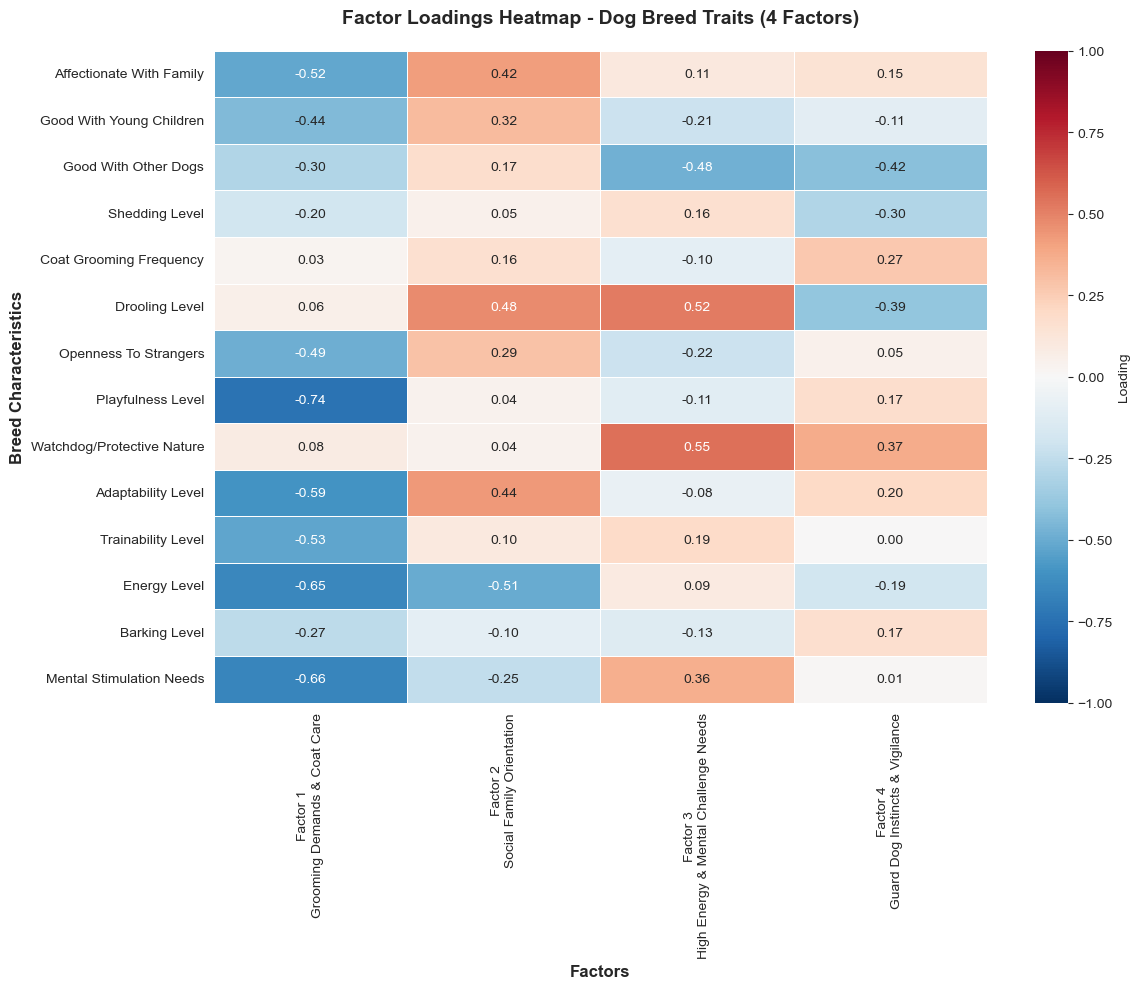

✓ Factor loadings heatmap saved


In [9]:
### 8.2 Heatmap of Factor Loadings
plt.figure(figsize=(12, 10))

# Create column labels with factor names
column_labels = [f"Factor {i+1}\n{factor_name_mapping[f'Factor {i+1}']}" 
                 for i in range(optimal_factors)]

sns.heatmap(factor_loadings_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Loading'}, linewidths=0.5, 
            vmin=-1, vmax=1, xticklabels=column_labels)
plt.title(f'Factor Loadings Heatmap - Dog Breed Traits ({optimal_factors} Factors)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Factors', fontsize=12, fontweight='bold')
plt.ylabel('Breed Characteristics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('factor_loadings_heatmap_dogs.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Factor loadings heatmap saved")

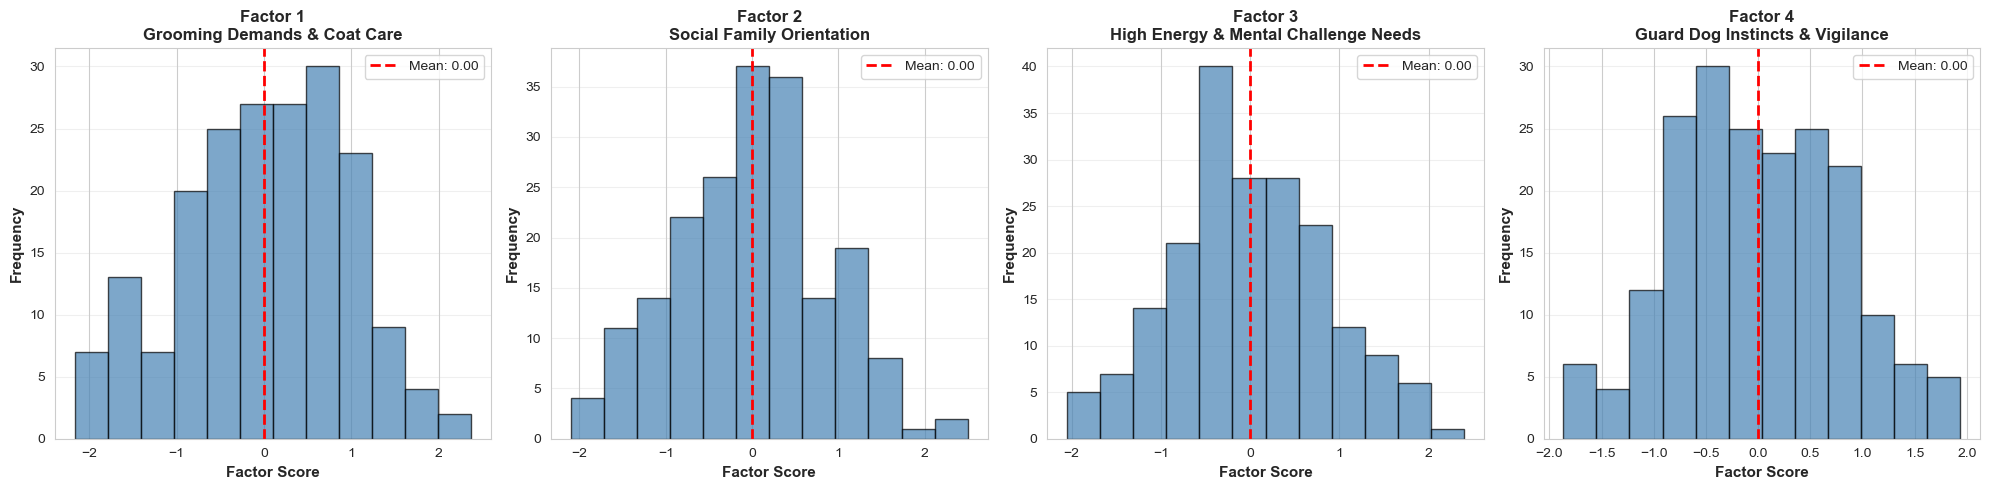

✓ Factor scores distribution saved


In [10]:
### 8.3 Factor Scores Distribution
fig, axes = plt.subplots(1, optimal_factors, figsize=(5*optimal_factors, 5))

if optimal_factors == 1:
    axes = [axes]

for idx, ax in enumerate(axes):
    factor_name = f'Factor {idx + 1}'
    factor_semantic_name = factor_name_mapping.get(factor_name, "")
    scores = factor_scores_df[factor_name]
    
    ax.hist(scores, bins=12, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {scores.mean():.2f}')
    ax.set_xlabel('Factor Score', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'{factor_name}\n{factor_semantic_name}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('factor_scores_distribution_dogs.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Factor scores distribution saved")

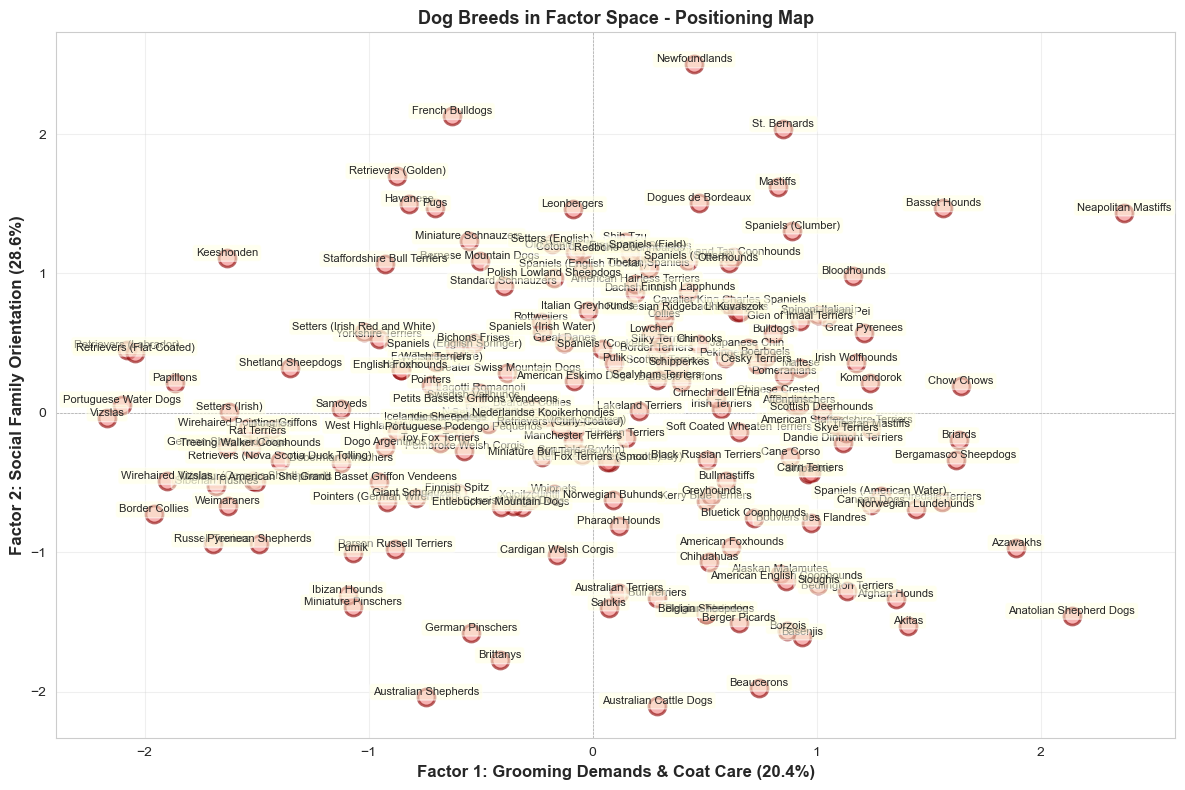

✓ Breed positioning map saved


In [11]:
### 8.4 Breed Positions in Factor Space
if optimal_factors >= 2:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot breed positions
    scatter = ax.scatter(factor_scores_df['Factor 1'], factor_scores_df['Factor 2'],
                        alpha=0.6, s=150, c='lightcoral', edgecolors='darkred', linewidth=2)
    
    # Add breed labels
    for idx, breed in enumerate(breed_names):
        ax.annotate(breed, 
                   (factor_scores_df.iloc[idx]['Factor 1'], factor_scores_df.iloc[idx]['Factor 2']),
                   fontsize=8, ha='center', va='bottom',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.5))
    
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.set_xlabel(f'Factor 1: {factor_name_mapping["Factor 1"]} ({variance_explained[0]*100:.1f}%)', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Factor 2: {factor_name_mapping["Factor 2"]} ({variance_explained[1]*100:.1f}%)', 
                 fontsize=12, fontweight='bold')
    ax.set_title('Dog Breeds in Factor Space - Positioning Map', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('breed_positioning_map.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Breed positioning map saved")
else:
    print("⚠ Positioning map requires at least 2 factors")

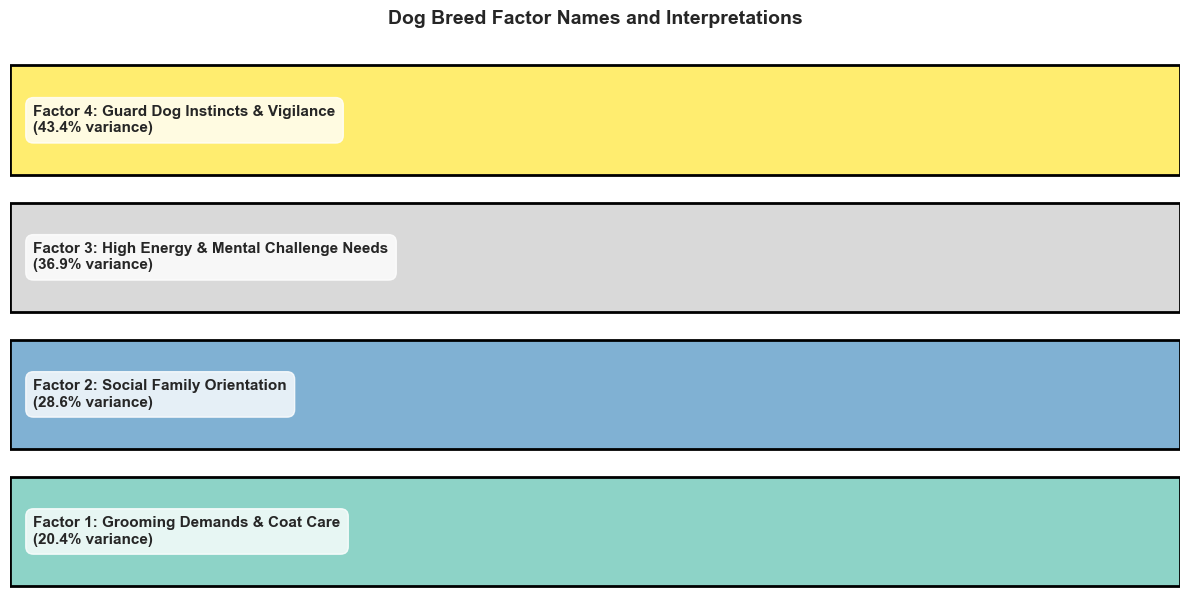

✓ Factor names summary visualization saved


In [12]:
### 8.5 Factor Names Summary Visualization
fig, ax = plt.subplots(figsize=(12, 3 + optimal_factors * 0.8))

# Prepare data for visualization
factor_nums = [f'Factor {i+1}' for i in range(optimal_factors)]
factor_names_list = [factor_name_mapping[f'Factor {i+1}'] for i in range(optimal_factors)]
variances = [f"{variance_explained[i]*100:.1f}%" for i in range(optimal_factors)]

# Create bars
y_pos = np.arange(optimal_factors)
colors = plt.cm.Set3(np.linspace(0, 1, optimal_factors))

bars = ax.barh(y_pos, [1]*optimal_factors, color=colors, edgecolor='black', linewidth=2)

# Add text
for i, (num, name, var) in enumerate(zip(factor_nums, factor_names_list, variances)):
    ax.text(0.02, i, f'{num}: {name}\n({var} variance)', 
           va='center', fontsize=11, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, optimal_factors - 0.5)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.title('Dog Breed Factor Names and Interpretations', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('factor_names_summary_dogs.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Factor names summary visualization saved")

## 9. Summary and Export Results

In [13]:
print("\n" + "="*70)
print("FACTOR ANALYSIS SUMMARY REPORT - DOG BREED TRAITS")
print("="*70)
print(f"\nDataset: Dog Breeds Characteristics")
print(f"Observations (Breeds): {X_scaled.shape[0]}")
print(f"Original Variables: {X_scaled.shape[1]}")
print(f"Optimal Number of Factors: {optimal_factors}")
print(f"Cumulative Variance Explained: {cumulative_variance[optimal_factors-1]*100:.2f}%")

print("\nKey Findings:")
print(f"  • Each of the {optimal_factors} factor{'s' if optimal_factors > 1 else ''} represents a distinct")
print(f"    dimension of dog breed characteristics")
print(f"  • Together, they explain {cumulative_variance[optimal_factors-1]*100:.1f}% of total trait variance")
print(f"  • Method used: Kaiser Criterion (eigenvalues > 1)")

print("\nFactor Interpretations Summary:")
for factor_idx in range(optimal_factors):
    factor_name = f'Factor {factor_idx + 1}'
    factor_semantic = factor_name_mapping[factor_name]
    print(f"\n  Factor {factor_idx + 1}: {factor_semantic}")
    
    # Top traits
    top_traits = factor_loadings_df[factor_name].nlargest(2)
    for trait, loading in top_traits.items():
        print(f"    • {trait}: {loading:.3f}")

print("\n" + "="*70)
print("\nPRACTICAL INSIGHTS FOR BREED SELECTION:")
print("-" * 70)

# Find breeds at extremes of each factor
for factor_idx in range(optimal_factors):
    factor_name = f'Factor {factor_idx + 1}'
    factor_semantic = factor_name_mapping[factor_name]
    
    # High scoring breeds
    high_breeds = factor_scores_df.nlargest(2, factor_name)
    low_breeds = factor_scores_df.nsmallest(2, factor_name)
    
    print(f"\n{factor_semantic.upper()}:")
    print(f"  High-scoring breeds: {', '.join(high_breeds['Breed'].values)}")
    print(f"  Low-scoring breeds: {', '.join(low_breeds['Breed'].values)}")

print("\n" + "="*70)

# Save results to CSV
factor_loadings_df.to_csv('factor_loadings_dogs.csv')
factor_scores_df.to_csv('factor_scores_dogs.csv')

print("\nFiles saved:")
print("  ✓ factor_loadings_dogs.csv")
print("  ✓ factor_scores_dogs.csv")
print("  ✓ scree_plot_dogs.png")
print("  ✓ factor_loadings_heatmap_dogs.png")
print("  ✓ factor_scores_distribution_dogs.png")
if optimal_factors >= 2:
    print("  ✓ breed_positioning_map.png")
print("  ✓ factor_names_summary_dogs.png")
print("\n" + "="*70)


FACTOR ANALYSIS SUMMARY REPORT - DOG BREED TRAITS

Dataset: Dog Breeds Characteristics
Observations (Breeds): 194
Original Variables: 14
Optimal Number of Factors: 4
Cumulative Variance Explained: 129.31%

Key Findings:
  • Each of the 4 factors represents a distinct
    dimension of dog breed characteristics
  • Together, they explain 129.3% of total trait variance
  • Method used: Kaiser Criterion (eigenvalues > 1)

Factor Interpretations Summary:

  Factor 1: Grooming Demands & Coat Care
    • Watchdog/Protective Nature: 0.081
    • Drooling Level: 0.056

  Factor 2: Social Family Orientation
    • Drooling Level: 0.476
    • Adaptability Level: 0.436

  Factor 3: High Energy & Mental Challenge Needs
    • Watchdog/Protective Nature: 0.554
    • Drooling Level: 0.523

  Factor 4: Guard Dog Instincts & Vigilance
    • Watchdog/Protective Nature: 0.367
    • Coat Grooming Frequency: 0.266


PRACTICAL INSIGHTS FOR BREED SELECTION:
------------------------------------------------------

## 10. Determine Optimal Number of Clusters

In [14]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Extract factor scores for clustering (exclude breed names)
factor_scores_for_clustering = factor_scores_df.drop('Breed', axis=1).values

# Test different numbers of clusters
max_k = min(len(breed_names) - 1, 10)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
k_range = range(2, max_k + 1)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(factor_scores_for_clustering)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(factor_scores_for_clustering, cluster_labels))
    davies_bouldin_scores.append(davies_bouldin_score(factor_scores_for_clustering, cluster_labels))

# Find optimal k using different metrics
from kneed import KneeLocator

# Elbow method
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
optimal_k_elbow = kl.elbow if kl.elbow is not None else 3

# Silhouette (higher is better)
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]

# Davies-Bouldin (lower is better)
optimal_k_db = k_range[np.argmin(davies_bouldin_scores)]

print("="*70)
print("OPTIMAL NUMBER OF CLUSTERS - ANALYSIS")
print("="*70)

print(f"\n1. ELBOW METHOD (Inertia):")
print(f"   Suggested optimal k: {optimal_k_elbow}")

print(f"\n2. SILHOUETTE SCORE (Higher is Better):")
for k, score in zip(k_range, silhouette_scores):
    marker = " ← BEST" if k == optimal_k_silhouette else ""
    print(f"   k={k}: {score:.4f}{marker}")

print(f"\n3. DAVIES-BOULDIN INDEX (Lower is Better):")
for k, score in zip(k_range, davies_bouldin_scores):
    marker = " ← BEST" if k == optimal_k_db else ""
    print(f"   k={k}: {score:.4f}{marker}")

# Select optimal k (use silhouette score as primary)
optimal_k = optimal_k_silhouette

print("\n" + "="*70)
print(f"RECOMMENDATION: Using k={optimal_k} clusters (Silhouette-based selection)")
print("="*70)

OPTIMAL NUMBER OF CLUSTERS - ANALYSIS

1. ELBOW METHOD (Inertia):
   Suggested optimal k: 5

2. SILHOUETTE SCORE (Higher is Better):
   k=2: 0.1942
   k=3: 0.2127
   k=4: 0.2278
   k=5: 0.2419 ← BEST
   k=6: 0.2244
   k=7: 0.2268
   k=8: 0.2195
   k=9: 0.2190
   k=10: 0.2207

3. DAVIES-BOULDIN INDEX (Lower is Better):
   k=2: 1.8129
   k=3: 1.5603
   k=4: 1.3233
   k=5: 1.1981 ← BEST
   k=6: 1.2227
   k=7: 1.2095
   k=8: 1.2662
   k=9: 1.2182
   k=10: 1.2127

RECOMMENDATION: Using k=5 clusters (Silhouette-based selection)


## 11. Perform K-Means Clustering with Optimal K

In [15]:
# Perform K-means clustering with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(factor_scores_for_clustering)

# Store results
factor_scores_df['Cluster'] = cluster_labels

# Calculate cluster statistics
print(f"\n✓ K-Means Clustering completed with k={optimal_k}")
print(f"\nCLUSTER DISTRIBUTION:")
for cluster_id in range(optimal_k):
    count = np.sum(cluster_labels == cluster_id)
    percentage = count / len(cluster_labels) * 100
    print(f"  Cluster {cluster_id}: {count} breeds ({percentage:.1f}%)")

# Show breeds in each cluster
print(f"\n\nBREED DISTRIBUTION BY CLUSTER:")
for cluster_id in range(optimal_k):
    breed_list = factor_scores_df[factor_scores_df['Cluster'] == cluster_id]['Breed'].values
    print(f"\n  Cluster {cluster_id}:")
    for i, breed in enumerate(breed_list, 1):
        print(f"    {i}. {breed}")

# Calculate cluster characteristics (mean factor scores)
print(f"\n\nCLUSTER CHARACTERISTICS (Mean Factor Scores):")
print("="*70)
for cluster_id in range(optimal_k):
    cluster_data = factor_scores_df[factor_scores_df['Cluster'] == cluster_id].drop(['Breed', 'Cluster'], axis=1)
    mean_scores = cluster_data.mean()
    
    print(f"\nCluster {cluster_id}:")
    for factor_name, score in mean_scores.items():
        semantic_name = factor_name_mapping.get(factor_name, "")
        print(f"  {factor_name} ({semantic_name}): {score:7.3f}")

print("\n" + "="*70)


✓ K-Means Clustering completed with k=5

CLUSTER DISTRIBUTION:
  Cluster 0: 39 breeds (20.1%)
  Cluster 1: 26 breeds (13.4%)
  Cluster 2: 40 breeds (20.6%)
  Cluster 3: 49 breeds (25.3%)
  Cluster 4: 40 breeds (20.6%)


BREED DISTRIBUTION BY CLUSTER:

  Cluster 0:
    1. Brittanys
    2. Chihuahuas
    3. Belgian Malinois
    4. Shiba Inu
    5. Akitas
    6. Australian Cattle Dogs
    7. Soft Coated Wheaten Terriers
    8. Airedale Terriers
    9. Bull Terriers
    10. Alaskan Malamutes
    11. Cardigan Welsh Corgis
    12. Cairn Terriers
    13. Anatolian Shepherd Dogs
    14. Basenjis
    15. Bouviers des Flandres
    16. Borzois
    17. Belgian Tervuren
    18. Belgian Sheepdogs
    19. Beaucerons
    20. Afghan Hounds
    21. Australian Terriers
    22. Bluetick Coonhounds
    23. Bedlington Terriers
    24. Greyhounds
    25. Salukis
    26. Briards
    27. Berger Picards
    28. Spaniels (American Water)
    29. Affenpinschers
    30. Bergamasco Sheepdogs
    31. Pharaoh Hounds

## 12. Name Clusters Based on Characteristics

In [16]:
# Function to generate cluster names based on factor characteristics
def name_clusters(factor_scores_df, factor_name_mapping, optimal_k):
    """
    Generate semantic names for clusters based on their factor score profiles.
    """
    cluster_names = {}
    cluster_descriptions = {}
    
    for cluster_id in range(optimal_k):
        cluster_data = factor_scores_df[factor_scores_df['Cluster'] == cluster_id].drop(['Breed', 'Cluster'], axis=1)
        mean_scores = cluster_data.mean()
        
        # Find the most distinctive factors (highest absolute scores)
        abs_scores = mean_scores.abs().nlargest(3)
        top_factors = abs_scores.index.tolist()
        
        # Create name based on distinctive characteristics
        name_parts = []
        for factor in top_factors:
            score = mean_scores[factor]
            semantic_name = factor_name_mapping.get(factor, factor).split('&')[0].strip()
            
            if score > 0.5:
                name_parts.append(f"High {semantic_name}")
            elif score < -0.5:
                name_parts.append(f"Low {semantic_name}")
        
        # Construct cluster name
        if len(name_parts) >= 2:
            cluster_name = " & ".join(name_parts[:2])
        elif len(name_parts) == 1:
            cluster_name = name_parts[0]
        else:
            cluster_name = f"Cluster {cluster_id}"
        
        # Create detailed description
        high_factors = mean_scores[mean_scores > 0.3].sort_values(ascending=False)
        low_factors = mean_scores[mean_scores < -0.3].sort_values()
        
        description = f"Cluster {cluster_id} - {cluster_name}"
        description += "\n  Characteristics:"
        if len(high_factors) > 0:
            description += "\n    ✓ High on:"
            for factor, score in high_factors.items():
                desc = factor_name_mapping.get(factor, factor)
                description += f"\n      • {desc} ({score:.2f})"
        if len(low_factors) > 0:
            description += "\n    ✗ Low on:"
            for factor, score in low_factors.items():
                desc = factor_name_mapping.get(factor, factor)
                description += f"\n      • {desc} ({score:.2f})"
        
        cluster_names[cluster_id] = cluster_name
        cluster_descriptions[cluster_id] = description
    
    return cluster_names, cluster_descriptions

# Generate cluster names
cluster_names, cluster_descriptions = name_clusters(factor_scores_df, factor_name_mapping, optimal_k)

print("\n" + "="*70)
print("CLUSTER NAMES AND DESCRIPTIONS")
print("="*70)

for cluster_id in range(optimal_k):
    print(f"\n{cluster_descriptions[cluster_id]}")

print("\n" + "="*70)


CLUSTER NAMES AND DESCRIPTIONS

Cluster 0 - Low Social Family Orientation & High Grooming Demands
  Characteristics:
    ✓ High on:
      • Grooming Demands & Coat Care (0.86)
    ✗ Low on:
      • Social Family Orientation (-1.01)

Cluster 1 - High High Energy & High Social Family Orientation
  Characteristics:
    ✓ High on:
      • High Energy & Mental Challenge Needs (1.08)
      • Social Family Orientation (0.81)
      • Grooming Demands & Coat Care (0.75)
    ✗ Low on:
      • Guard Dog Instincts & Vigilance (-0.61)

Cluster 2 - Low Grooming Demands
  Characteristics:
    ✓ High on:
      • High Energy & Mental Challenge Needs (0.42)
    ✗ Low on:
      • Grooming Demands & Coat Care (-1.10)
      • Social Family Orientation (-0.43)
      • Guard Dog Instincts & Vigilance (-0.32)

Cluster 3 - High Guard Dog Instincts
  Characteristics:
    ✓ High on:
      • Guard Dog Instincts & Vigilance (0.93)

Cluster 4 - Low High Energy & High Social Family Orientation
  Characteristics:
  

## 12.5 Generate Cluster Summaries (3-Sentence Descriptions)

In [17]:
# Generate 3-sentence cluster summaries
def generate_cluster_summaries(factor_scores_df, factor_name_mapping, optimal_k):
    """
    Generate three-sentence descriptions for each cluster:
    1. Overview of the cluster
    2. Specific strengths
    3. Specific weaknesses
    """
    cluster_summaries = {}
    
    for cluster_id in range(optimal_k):
        cluster_data = factor_scores_df[factor_scores_df['Cluster'] == cluster_id].drop(['Breed', 'Cluster'], axis=1)
        mean_scores = cluster_data.mean()
        
        # Identify strong positive and negative factors
        strong_positive = mean_scores[mean_scores > 0.5].sort_values(ascending=False)
        strong_negative = mean_scores[mean_scores < -0.5].sort_values()
        
        # Get cluster name
        cluster_name = cluster_names[cluster_id]
        breed_count = len(factor_scores_df[factor_scores_df['Cluster'] == cluster_id])
        
        # Sentence 1: Overview (what is this cluster about?)
        if strong_positive.empty and strong_negative.empty:
            overview = f"This cluster comprises {breed_count} dog breeds characterized by balanced trait profiles."
        else:
            key_traits = []
            if len(strong_positive) > 0:
                key_traits.append(strong_positive.index[0].replace('Factor ', ''))
            if len(strong_negative) > 0:
                key_traits.append(strong_negative.index[0].replace('Factor ', ''))
            overview = f"This cluster of {breed_count} dog breeds is defined by '{cluster_name}' characteristics."
        
        # Sentence 2: Strengths (high-scoring factors - what are they good at?)
        if len(strong_positive) > 0:
            strength_factors = []
            for factor, score in strong_positive.items():
                factor_desc = factor_name_mapping.get(factor, factor).lower()
                strength_factors.append(factor_desc)
            
            if len(strength_factors) == 1:
                strengths = f"These breeds excel in {strength_factors[0]}."
            elif len(strength_factors) == 2:
                strengths = f"These breeds excel in {strength_factors[0]} and {strength_factors[1]}."
            else:
                factors_str = ", ".join(strength_factors[:-1]) + f", and {strength_factors[-1]}"
                strengths = f"These breeds excel in {factors_str}."
        else:
            strengths = "These breeds demonstrate balanced strengths across multiple dimensions."
        
        # Sentence 3: Weaknesses (low-scoring factors - areas of limitation)
        if len(strong_negative) > 0:
            weakness_factors = []
            for factor, score in strong_negative.items():
                factor_desc = factor_name_mapping.get(factor, factor).lower()
                weakness_factors.append(factor_desc)
            
            if len(weakness_factors) == 1:
                weaknesses = f"However, they show limitations in {weakness_factors[0]}."
            elif len(weakness_factors) == 2:
                weaknesses = f"However, they show limitations in {weakness_factors[0]} and {weakness_factors[1]}."
            else:
                factors_str = ", ".join(weakness_factors[:-1]) + f", and {weakness_factors[-1]}"
                weaknesses = f"However, they show limitations in {factors_str}."
        else:
            weaknesses = "These breeds lack significant weaknesses in the analyzed dimensions."
        
        # Combine into three-sentence summary
        summary = f"{overview} {strengths} {weaknesses}"
        cluster_summaries[cluster_id] = summary
    
    return cluster_summaries

# Generate summaries
cluster_summaries = generate_cluster_summaries(factor_scores_df, factor_name_mapping, optimal_k)

# Display cluster summaries
print("\n" + "="*80)
print("CLUSTER SUMMARIES (3-SENTENCE DESCRIPTIONS)")
print("="*80)

for cluster_id in range(optimal_k):
    print(f"\n📌 Cluster {cluster_id}: {cluster_names[cluster_id].upper()}")
    print("-" * 80)
    print(f"{cluster_summaries[cluster_id]}")
    
    # Show breed members
    cluster_breeds = factor_scores_df[factor_scores_df['Cluster'] == cluster_id]['Breed'].tolist()
    print(f"\n   Member Breeds ({len(cluster_breeds)}): {', '.join(cluster_breeds)}")

print("\n" + "="*80)


CLUSTER SUMMARIES (3-SENTENCE DESCRIPTIONS)

📌 Cluster 0: LOW SOCIAL FAMILY ORIENTATION & HIGH GROOMING DEMANDS
--------------------------------------------------------------------------------
This cluster of 39 dog breeds is defined by 'Low Social Family Orientation & High Grooming Demands' characteristics. These breeds excel in grooming demands & coat care. However, they show limitations in social family orientation.

   Member Breeds (39): Brittanys, Chihuahuas, Belgian Malinois, Shiba Inu, Akitas, Australian Cattle Dogs, Soft Coated Wheaten Terriers, Airedale Terriers, Bull Terriers, Alaskan Malamutes, Cardigan Welsh Corgis, Cairn Terriers, Anatolian Shepherd Dogs, Basenjis, Bouviers des Flandres, Borzois, Belgian Tervuren, Belgian Sheepdogs, Beaucerons, Afghan Hounds, Australian Terriers, Bluetick Coonhounds, Bedlington Terriers, Greyhounds, Salukis, Briards, Berger Picards, Spaniels (American Water), Affenpinschers, Bergamasco Sheepdogs, Pharaoh Hounds, Dandie Dinmont Terriers, 

## 13. Visualize Clusters

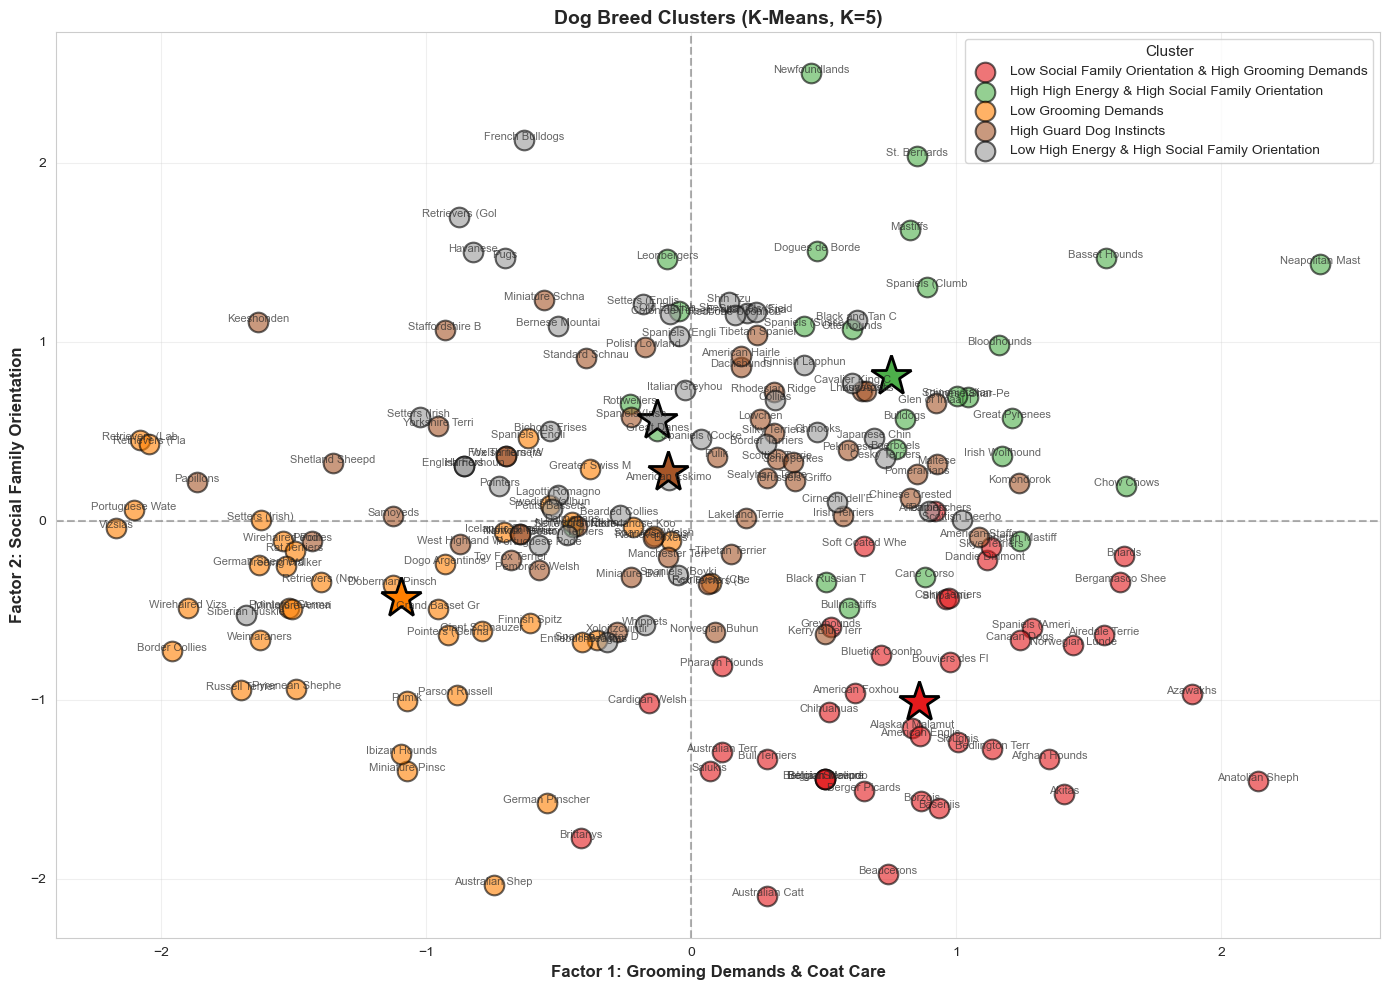


2D cluster visualization saved as 'dog_breed_clusters_2d.png'


In [75]:
# Create 2D cluster visualization using top 2 factors
fig, ax = plt.subplots(figsize=(14, 10))

colors = plt.cm.Set1(np.linspace(0, 1, optimal_k))
cluster_colors = {i: colors[i] for i in range(optimal_k)}

# Plot each cluster
for cluster_id in range(optimal_k):
    cluster_mask = factor_scores_df['Cluster'] == cluster_id
    ax.scatter(
        factor_scores_df.loc[cluster_mask, 'Factor 1'],
        factor_scores_df.loc[cluster_mask, 'Factor 2'],
        c=[cluster_colors[cluster_id]],
        label=cluster_names[cluster_id],
        s=200,
        alpha=0.6,
        edgecolors='black',
        linewidth=1.5
    )
    
    # Add breed labels
    for idx, row in factor_scores_df[cluster_mask].iterrows():
        ax.annotate(
            row['Breed'][:15],  # Truncate long names
            (row['Factor 1'], row['Factor 2']),
            fontsize=8,
            alpha=0.7,
            ha='center'
        )
    
    # Plot cluster centroid
    centroid_x = factor_scores_df.loc[cluster_mask, 'Factor 1'].mean()
    centroid_y = factor_scores_df.loc[cluster_mask, 'Factor 2'].mean()
    ax.plot(centroid_x, centroid_y, marker='*', markersize=30, 
            color=cluster_colors[cluster_id], markeredgecolor='black', markeredgewidth=2)

ax.set_xlabel(f'Factor 1: {factor_name_mapping["Factor 1"]}', fontsize=12, fontweight='bold')
ax.set_ylabel(f'Factor 2: {factor_name_mapping["Factor 2"]}', fontsize=12, fontweight='bold')
ax.set_title(f'Dog Breed Clusters (K-Means, K={optimal_k})', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, title='Cluster', title_fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('dog_breed_clusters_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n2D cluster visualization saved as 'dog_breed_clusters_2d.png'")

## 14. Cluster Heatmap: Mean Factor Scores by Cluster

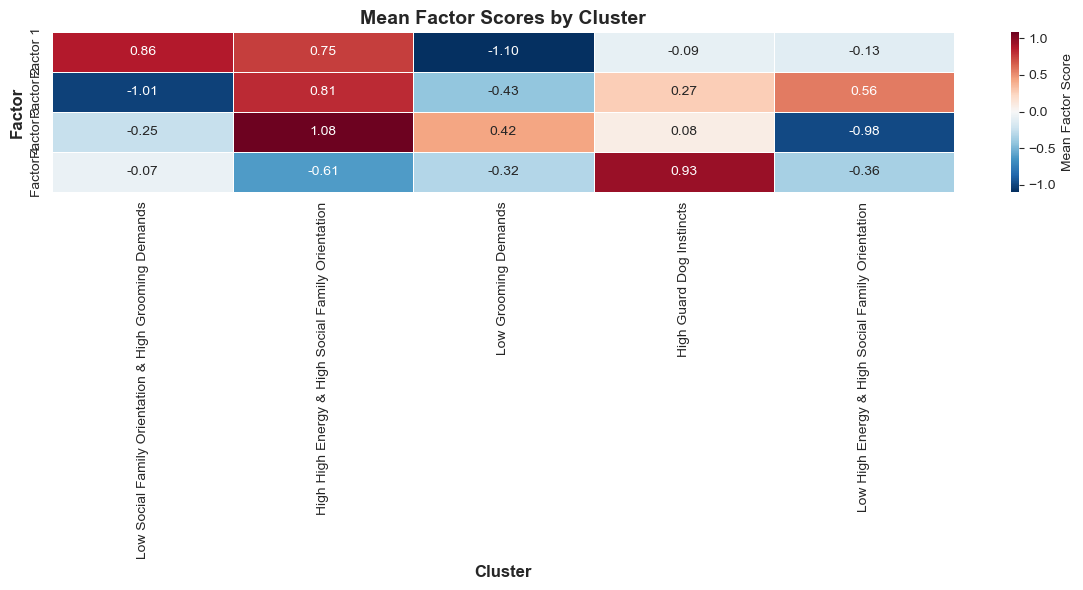

Cluster factor score heatmap saved as 'cluster_factor_heatmap.png'


In [76]:
# Create heatmap of mean factor scores by cluster
cluster_factor_means = []
for cluster_id in range(optimal_k):
    cluster_data = factor_scores_df[factor_scores_df['Cluster'] == cluster_id].drop(['Breed', 'Cluster'], axis=1)
    cluster_factor_means.append(cluster_data.mean())

cluster_matrix = pd.DataFrame(cluster_factor_means)
cluster_matrix.index = [cluster_names[i] for i in range(optimal_k)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cluster_matrix.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Mean Factor Score'}, ax=ax, linewidths=0.5)
ax.set_title('Mean Factor Scores by Cluster', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Factor', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_factor_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Cluster factor score heatmap saved as 'cluster_factor_heatmap.png'")

## 15. Summary Report

In [77]:
# Generate comprehensive summary report
print("\n" + "="*70)
print("DOG BREED CLUSTERING ANALYSIS - SUMMARY REPORT")
print("="*70)

print(f"\n📊 OPTIMAL NUMBER OF CLUSTERS: {optimal_k}")
print(f"   • Silhouette Score: {max(silhouette_scores):.3f}")
print(f"   • Davies-Bouldin Index: {davies_bouldin_scores[optimal_k-2]:.3f}")
print(f"   • Inertia: {inertias[optimal_k-2]:.1f}")

print(f"\n📈 CLUSTER DISTRIBUTION:")
for cluster_id in range(optimal_k):
    count = (factor_scores_df['Cluster'] == cluster_id).sum()
    percentage = (count / len(factor_scores_df)) * 100
    print(f"   {cluster_names[cluster_id]}: {count} breeds ({percentage:.1f}%)")

print(f"\n🐕 CLUSTER DETAILS:")
for cluster_id in range(optimal_k):
    cluster_breeds = factor_scores_df[factor_scores_df['Cluster'] == cluster_id]['Breed'].tolist()
    print(f"\n   {cluster_names[cluster_id]} ({len(cluster_breeds)} breeds):")
    print(f"   {', '.join(cluster_breeds[:5])}", end='')
    if len(cluster_breeds) > 5:
        print(f", +{len(cluster_breeds)-5} more")
    else:
        print()

print(f"\n💡 INTERPRETATION:")
print(f"   This clustering analysis identifies {optimal_k} distinct dog breed groups")
print(f"   based on their behavioral and physical characteristics (factors).")
print(f"   Each cluster represents breeds with similar trait profiles.")

print("\n" + "="*70)

# Export results
clustering_results = factor_scores_df.copy()
clustering_results['Cluster_Name'] = clustering_results['Cluster'].map(cluster_names)
clustering_results.to_csv('dog_breeds_with_clusters.csv', index=False)
print(f"\n✅ Results exported to 'dog_breeds_with_clusters.csv'")
print(f"✅ Visualizations saved as 'dog_breed_clusters_2d.png' and 'cluster_factor_heatmap.png'")


DOG BREED CLUSTERING ANALYSIS - SUMMARY REPORT

📊 OPTIMAL NUMBER OF CLUSTERS: 5
   • Silhouette Score: 0.242
   • Davies-Bouldin Index: 1.198
   • Inertia: 260.2

📈 CLUSTER DISTRIBUTION:
   Low Social Family Orientation & High Grooming Demands: 39 breeds (20.1%)
   High High Energy & High Social Family Orientation: 26 breeds (13.4%)
   Low Grooming Demands: 40 breeds (20.6%)
   High Guard Dog Instincts: 49 breeds (25.3%)
   Low High Energy & High Social Family Orientation: 40 breeds (20.6%)

🐕 CLUSTER DETAILS:

   Low Social Family Orientation & High Grooming Demands (39 breeds):
   Brittanys, Chihuahuas, Belgian Malinois, Shiba Inu, Akitas, +34 more

   High High Energy & High Social Family Orientation (26 breeds):
   Bulldogs, Rottweilers, Great Danes, Cane Corso, Mastiffs, +21 more

   Low Grooming Demands (40 breeds):
   Retrievers (Labrador), German Shepherd Dogs, Pointers (German Shorthaired), Australian Shepherds, Boxers, +35 more

   High Guard Dog Instincts (49 breeds):
   Po

## 16 Generate Individual Breed Summaries

In [78]:
# Function to generate 3-sentence breed summary
def generate_breed_summary(breed_name, factor_scores_df, factor_name_mapping):
    """
    Generate a three-sentence summary for an individual breed:
    1. Strengths based on high-scoring factors
    2. Weaknesses/average aspects based on low-scoring factors
    3. Concluding statement about the breed
    """
    # Find the breed in the dataframe
    parts = breed_name.split()
    pattern = ".*".join(parts) 
    
    breed_row = factor_scores_df[factor_scores_df['Breed'].str.contains(pattern, case=False, na=False, regex=True)]

    
    # Get factor scores (exclude 'Breed' and 'Cluster' columns)
    factor_cols = [col for col in factor_scores_df.columns if col.startswith('Factor')]
   
    breed_scores = breed_row[factor_cols].iloc[0] 


    
    # Identify strong positive and negative factors
    strong_positive = breed_scores[breed_scores > 0.5].sort_values(ascending=False)
    strong_negative = breed_scores[breed_scores < -0.5].sort_values()
    moderate = breed_scores[(breed_scores >= -0.5) & (breed_scores <= 0.5)]
    
    # Get cluster assignment
    cluster_id = int(breed_row['Cluster'])
    cluster_name = cluster_names[cluster_id]
    
    # Sentence 1: Strengths (high-scoring factors)
    if len(strong_positive) > 0:
        strength_factors = []
        for factor, score in strong_positive.items():
            factor_desc = factor_name_mapping.get(factor, factor).lower()
            strength_factors.append(factor_desc)
        
        if len(strength_factors) == 1:
            sentence1 = f"{breed_name} excels in {strength_factors[0]}."
        elif len(strength_factors) == 2:
            sentence1 = f"{breed_name} excels in {strength_factors[0]} and {strength_factors[1]}."
        else:
            factors_str = ", ".join(strength_factors[:-1]) + f", and {strength_factors[-1]}"
            sentence1 = f"{breed_name} excels in {factors_str}."
    else:
        sentence1 = f"{breed_name} demonstrates balanced strengths across multiple dimensions."
    
    # Sentence 2: Weaknesses/average aspects (low-scoring or moderate factors)
    if len(strong_negative) > 0:
        weakness_factors = []
        for factor, score in strong_negative.items():
            factor_desc = factor_name_mapping.get(factor, factor).lower()
            weakness_factors.append(factor_desc)
        
        if len(weakness_factors) == 1:
            sentence2 = f"However, it shows limitations in {weakness_factors[0]}."
        elif len(weakness_factors) == 2:
            sentence2 = f"However, it shows limitations in {weakness_factors[0]} and {weakness_factors[1]}."
        else:
            factors_str = ", ".join(weakness_factors[:-1]) + f", and {weakness_factors[-1]}"
            sentence2 = f"However, it shows limitations in {factors_str}."
    elif len(moderate) > 0:
        moderate_factors = []
        for factor, score in moderate.items():
            factor_desc = factor_name_mapping.get(factor, factor).lower()
            moderate_factors.append(factor_desc)
        
        if len(moderate_factors) <= 2:
            factors_str = " and ".join(moderate_factors)
        else:
            factors_str = ", ".join(moderate_factors[:-1]) + f", and {moderate_factors[-1]}"
        sentence2 = f"In {factors_str}, it demonstrates average characteristics."
    else:
        sentence2 = "It lacks significant weaknesses in the analyzed dimensions."
    
    # Sentence 3: Concluding statement (cluster classification and overall character)
    sentence3 = f"Overall, {breed_name} is a {cluster_name} breed, making it well-suited for its natural role and temperament profile."
    
    # Combine into complete summary
    summary = f"{sentence1} {sentence2} {sentence3}"
    
    return summary

# Generate summary for Great Pyrenees
breed_to_analyze = "Great Pyrenees"
great_pyrenees_summary = generate_breed_summary(breed_to_analyze, factor_scores_df, factor_name_mapping)

print("\n" + "="*80)
print(f"INDIVIDUAL BREED SUMMARY: {breed_to_analyze.upper()}")
print("="*80)
print(f"\n{great_pyrenees_summary}")
print("\n" + "="*80)


INDIVIDUAL BREED SUMMARY: GREAT PYRENEES

Great Pyrenees excels in grooming demands & coat care, high energy & mental challenge needs, and social family orientation. In guard dog instincts & vigilance, it demonstrates average characteristics. Overall, Great Pyrenees is a High High Energy & High Social Family Orientation breed, making it well-suited for its natural role and temperament profile.

